# Using SHAP Interpretability

I loaded in the model and then used different shap features to look at how the model makes predictions based on an email I got from a running organization (A safe email).

In [1]:
def set_seed(seed_value=42):
    import random
    import numpy as np
    import torch

    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)

In [2]:
from datasets import Dataset
import torch

class MyDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

In [3]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_path = "./phishing_model"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [2]:
print(model.config)


RobertaConfig {
  "add_cross_attention": false,
  "architectures": [
    "RobertaForSequenceClassification"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 514,
  "model_type": "roberta",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 1,
  "problem_type": "single_label_classification",
  "tie_word_embeddings": true,
  "transformers_version": "5.3.0",
  "type_vocab_size": 1,
  "use_cache": false,
  "vocab_size": 50265
}



In [5]:
import shap
from transformers import pipeline

# Wrap model in a pipeline
pipe = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    return_all_scores=True,
    device=0 if torch.cuda.is_available() else -1
)

# Build the explainer
explainer = shap.Explainer(pipe)

In [7]:
texts = ["Congratulations to all who raced Longhorn Run, and a big shoutout to those who paced it!! What a fun way to spend our Saturday with our community! However, it is with a heavy heart that I am officially writing my last email to you all. That also means that we are in the home stretch of things! Let's see what these last few days together have in store for us."]
shap_values = explainer(texts)

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:22, 22.89s/it]                            


In [8]:
shap.plots.text(shap_values[0])

Based on the results, it seems a majority of the phrases that were recognized as safe are community based and friendly. The model was able to put importance on phrases as opposed to individual tokens.

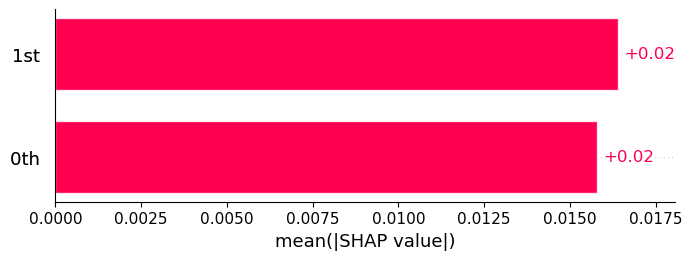

In [50]:
import shap
import numpy as np

# Option 1: Sum across tokens to get per-class feature importance
sv = shap_values[0]  # single example

# Create a clean Explanation without clustering
clean_exp = shap.Explanation(
    values=sv.values,
    base_values=sv.base_values,
    data=sv.data,
    feature_names=sv.data  # token strings as feature names
)

shap.plots.bar(clean_exp)

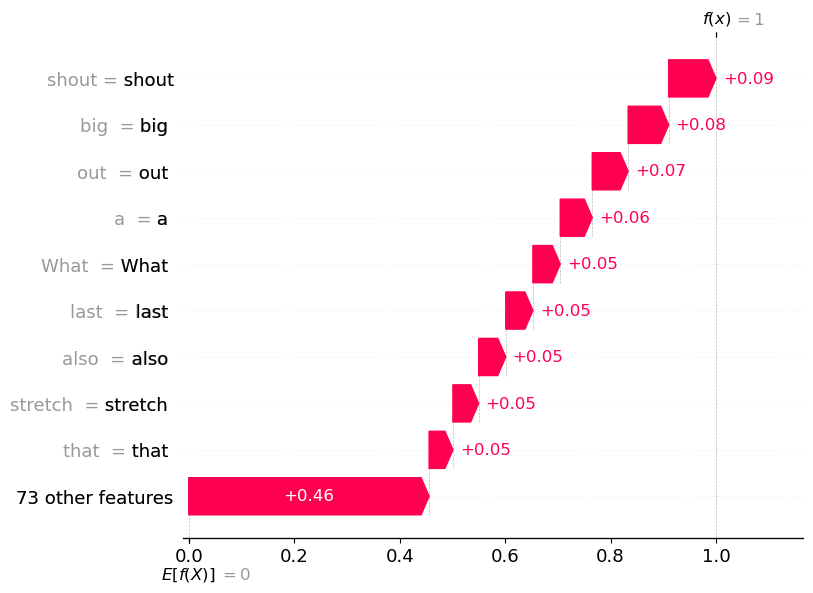

In [51]:
# Pick class index (0 = LABEL_0, 1 = LABEL_1)
class_idx = 0

clean_exp = shap.Explanation(
    values=sv.values[:, class_idx],
    base_values=sv.base_values[class_idx],
    data=sv.data,
    feature_names=sv.data
)

shap.plots.waterfall(clean_exp)

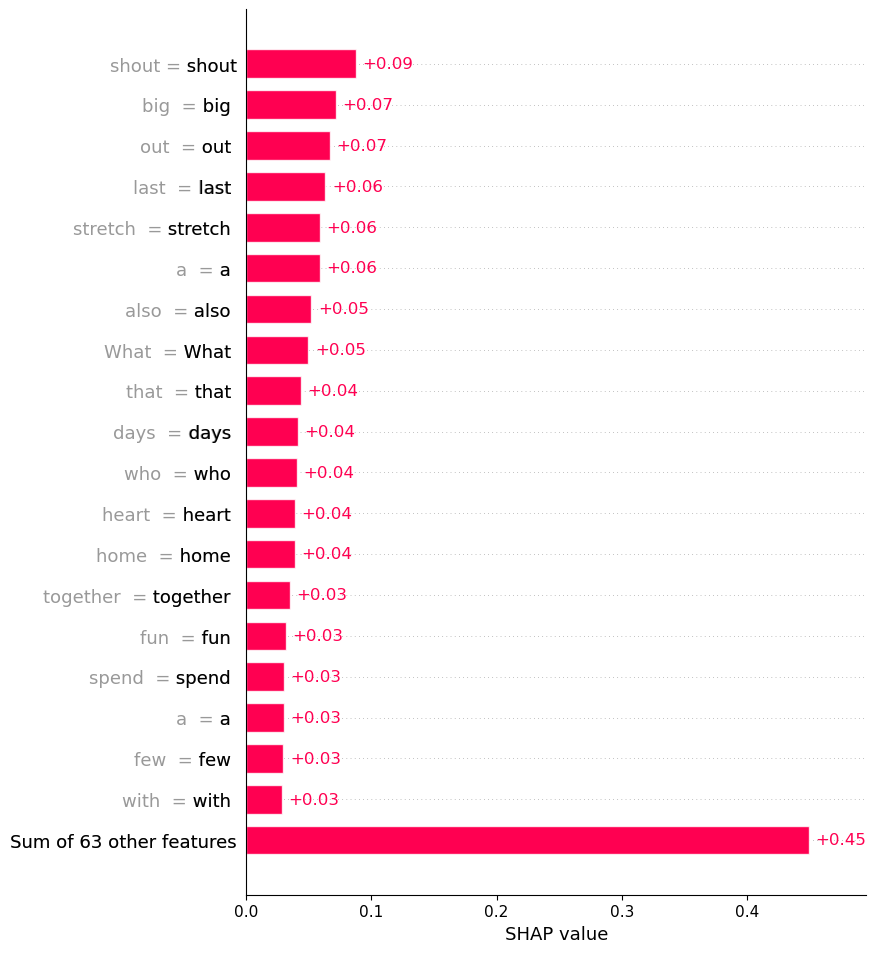

In [52]:
# Stack all examples
all_values = np.array([shap_values[i].values for i in range(len(shap_values))])
# all_values shape: (n_examples, n_tokens, n_classes)

# Mean absolute importance per token per class
mean_vals = np.abs(all_values).mean(axis=0)  # (n_tokens, n_classes)

# For a single class
class_idx = 1
tokens = shap_values[0].data  # token strings

clean_exp = shap.Explanation(
    values=mean_vals[:, class_idx],
    base_values=shap_values[0].base_values[class_idx],
    data=tokens,
    feature_names=list(tokens)
)

shap.plots.bar(clean_exp, max_display=20)

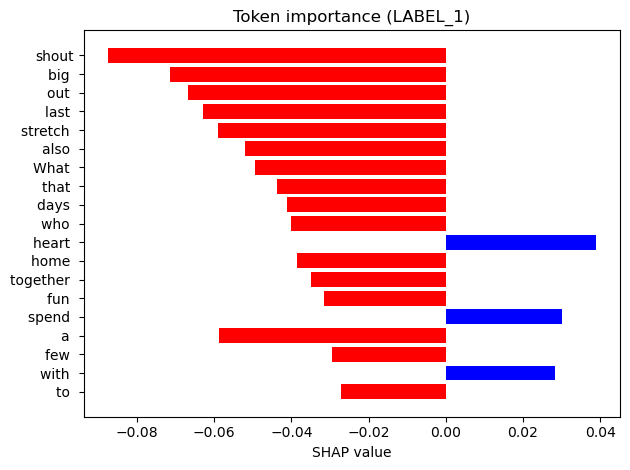

In [53]:
import matplotlib.pyplot as plt

sv = shap_values[0]
class_idx = 1  # LABEL_1

tokens = list(sv.data)
values = sv.values[:, class_idx]

# Sort by absolute value
sorted_idx = np.argsort(np.abs(values))[-20:]  # top 20
colors = ["red" if v < 0 else "blue" for v in values[sorted_idx]]

plt.barh([tokens[i] for i in sorted_idx], values[sorted_idx], color=colors)
plt.xlabel("SHAP value")
plt.title("Token importance (LABEL_1)")
plt.tight_layout()
plt.show()